# **Prediksi Konversi Pengunjung E-Commerce Berdasarkan Perilaku Browsing Customer**

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


## 1. Load Dataset

In [29]:
df = pd.read_csv("online_shoppers_intention.csv")

df.info()
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

print(df.columns.tolist())
df.describe(include="all").T
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 2. Exploratory Data Analysis (EDA)

### A. Cek Missing Value

In [30]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Value": missing,
    "Persentase (%)": (missing / len(df) * 100).round(2)
})

missing_df

,Missing Value,Persentase (%)
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


### B. Cek Duplikat

In [31]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 125


In [32]:
df = df.drop_duplicates()

print("Jumlah data setelah menghapus duplikat:", len(df))

Jumlah data setelah menghapus duplikat: 12205


### C. Distribusi Target

In [33]:
print(df["Revenue"].value_counts())

Revenue
False    10297
True      1908
Name: count, dtype: int64


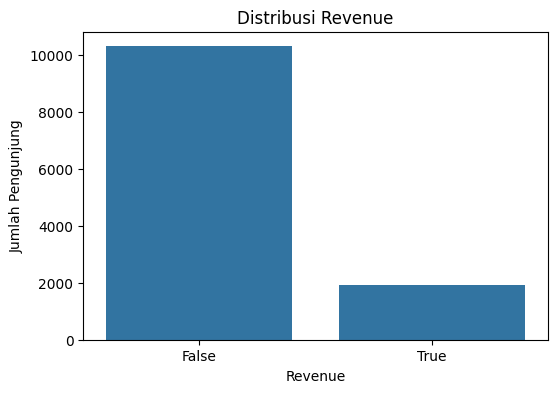

Revenue
False    84.37
True     15.63
Name: proportion, dtype: float64


In [34]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Revenue")

plt.title("Distribusi Revenue")
plt.xlabel("Revenue")
plt.ylabel("Jumlah Pengunjung")

plt.show()
revenue_percentage = df["Revenue"].value_counts(normalize=True) * 100

print(revenue_percentage.round(2))

### D. Distribusi variabel numerik

In [35]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12205.0,2.338878,3.330436,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12205.0,81.646331,177.491845,0.0,0.000000,9.000000,94.700000,3398.750000
Informational,12205.0,0.508726,1.275617,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12205.0,34.825454,141.424807,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12205.0,32.045637,44.593649,0.0,8.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12205.0,1206.982457,1919.601400,0.0,193.000000,608.942857,1477.154762,63973.522230
BounceRates,12205.0,0.020370,0.045255,0.0,0.000000,0.002899,0.016667,0.200000
ExitRates,12205.0,0.041466,0.046163,0.0,0.014231,0.025000,0.048529,0.200000
PageValues,12205.0,5.949574,18.653671,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12205.0,0.061942,0.199666,0.0,0.000000,0.000000,0.000000,1.000000


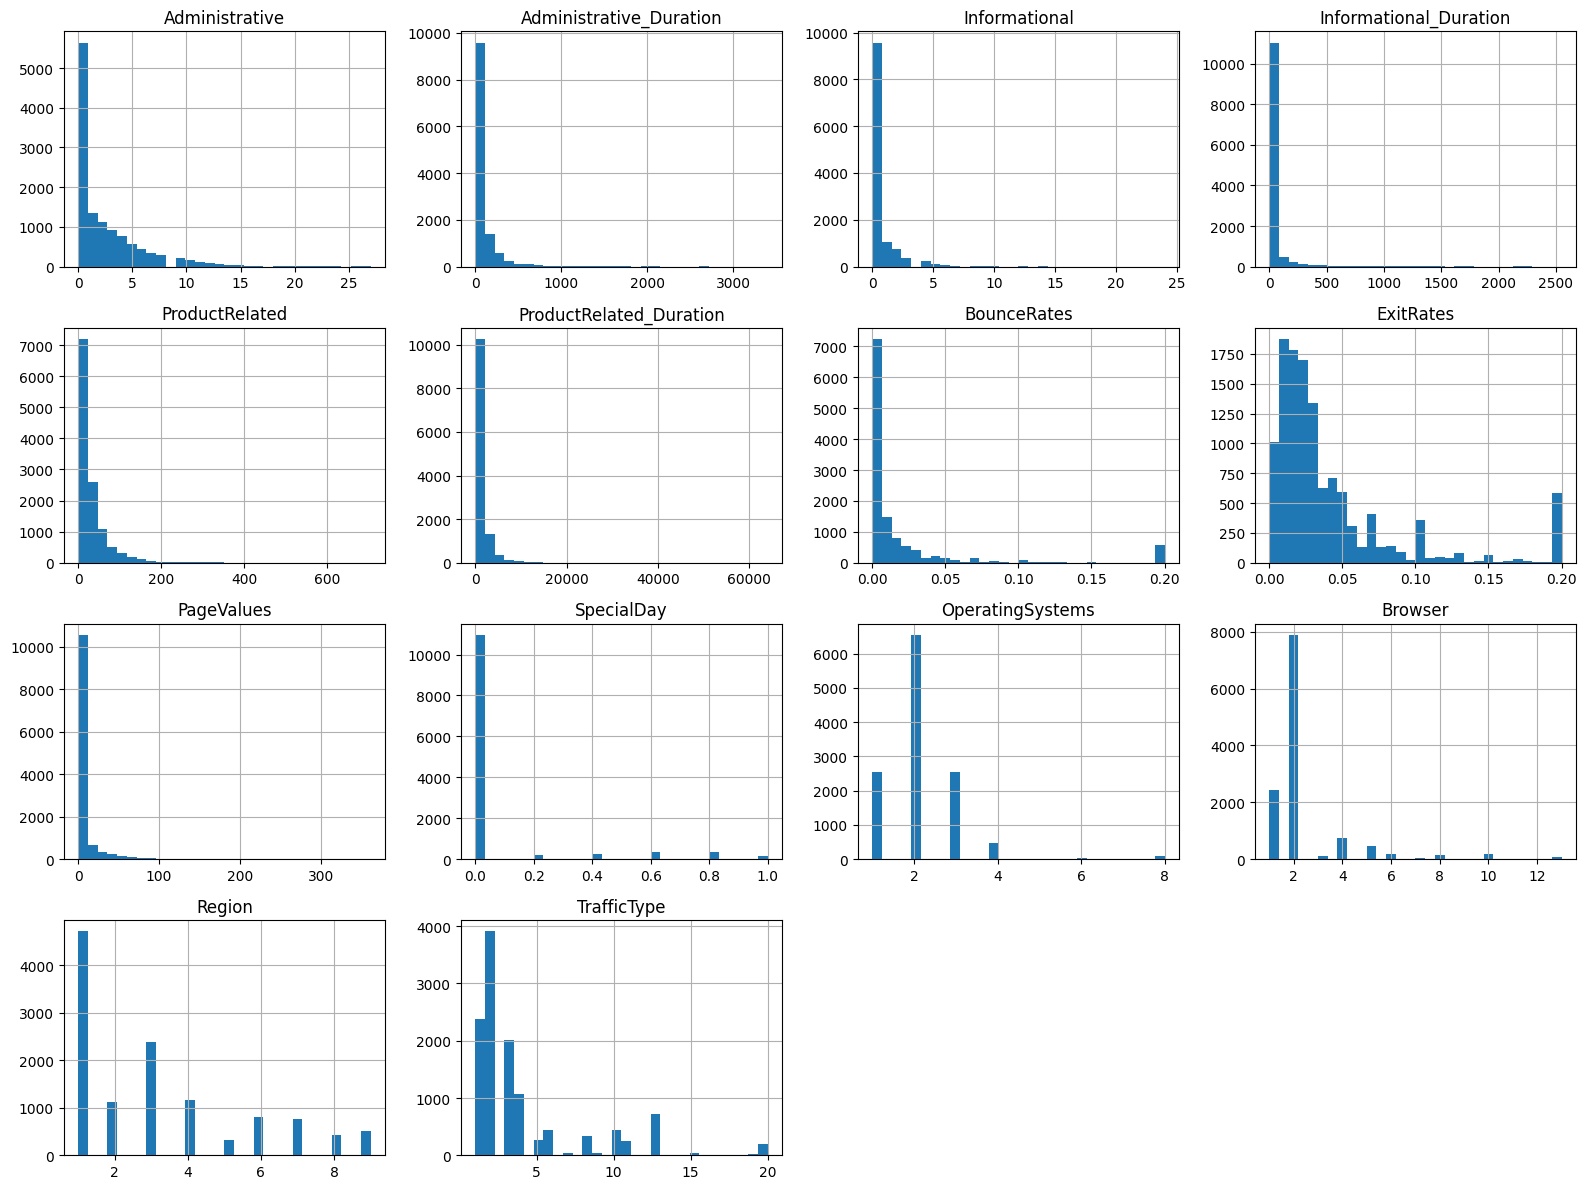

In [36]:
df[numeric_cols].hist(
    figsize=(16, 12),
    bins=30
)

plt.tight_layout()
plt.show()

### E. Distribusi variabel kategorikal

In [ ]:
categorical_cols = df.select_dtypes(
    include=["object", "bool"]
).columns

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== Month =====
Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64

===== VisitorType =====
VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64

===== Weekend =====
Weekend
False    9346
True     2859
Name: count, dtype: int64

===== Revenue =====
Revenue
False    10297
True      1908
Name: count, dtype: int64


### F. Hubungan fitur numerik dengan Revenue

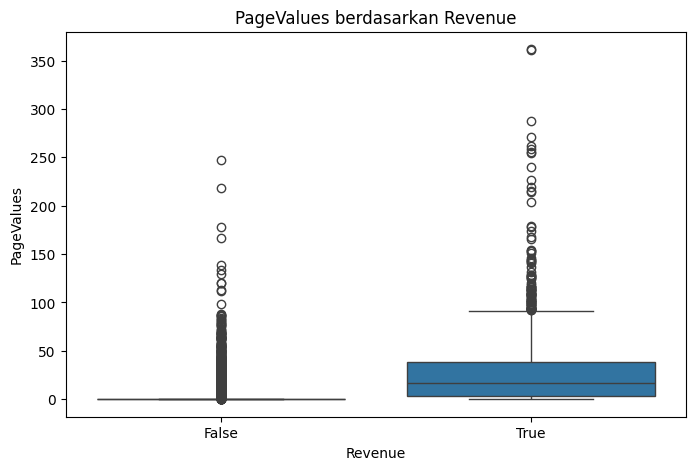

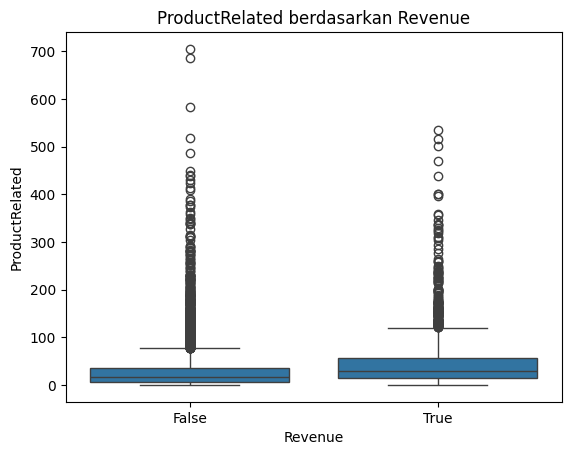

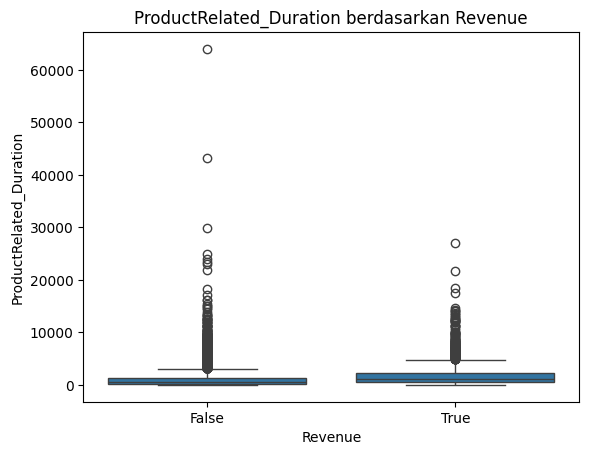

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="PageValues"
)

plt.title("PageValues berdasarkan Revenue")
plt.show()

sns.boxplot(
    data=df,
    x="Revenue",
    y="ProductRelated"
)

plt.title("ProductRelated berdasarkan Revenue")
plt.show()

sns.boxplot(
    data=df,
    x="Revenue",
    y="ProductRelated_Duration"
)

plt.title("ProductRelated_Duration berdasarkan Revenue")
plt.show()

### G. Korelasi fitur numerik

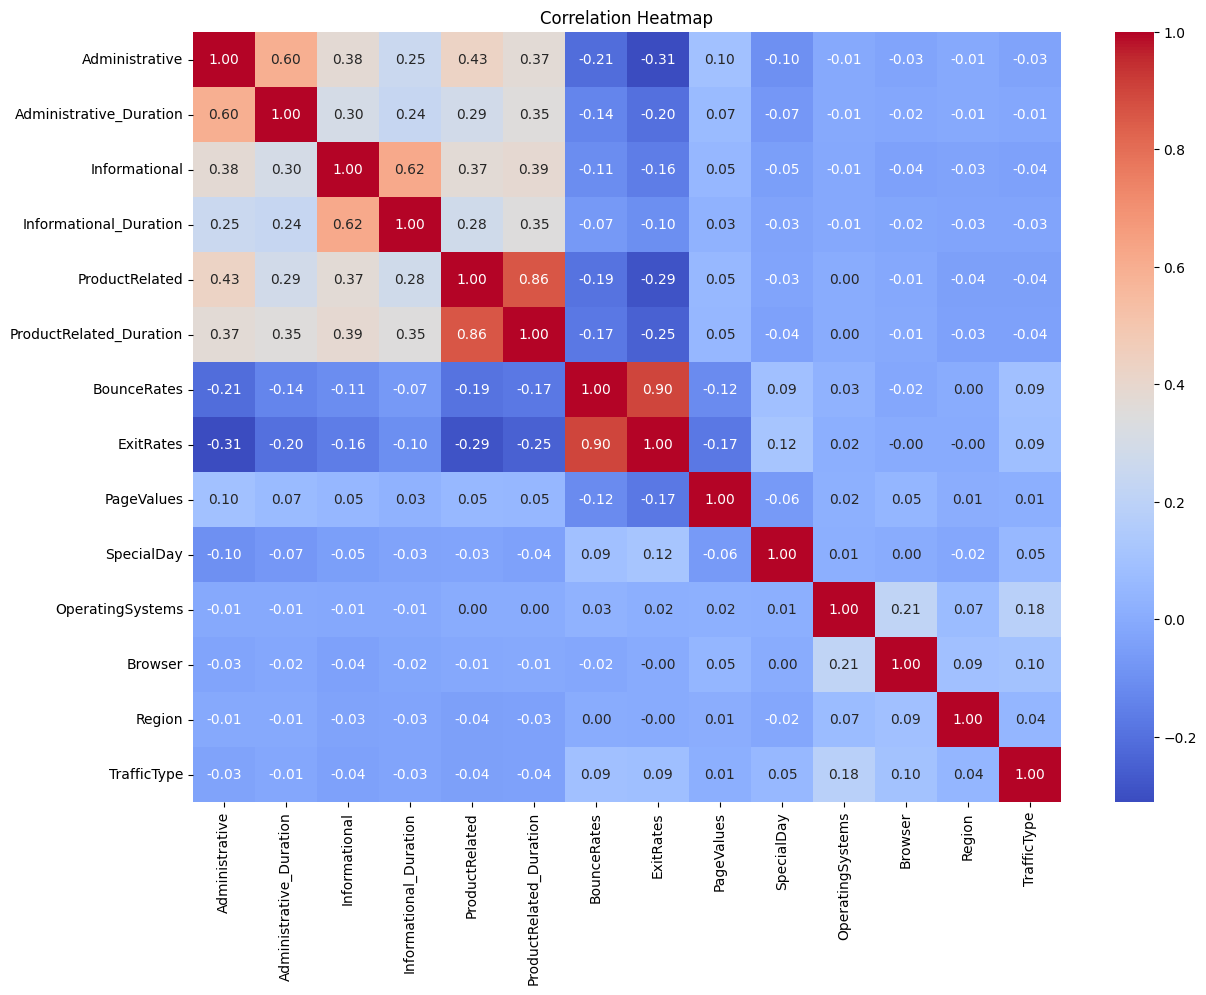

In [ ]:
plt.figure(figsize=(14, 10))

correlation = df[numeric_cols].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

## 3. Preproccessing

### A. Mengubah target 

False = 0
True = 1

In [40]:
df["Revenue"] = df["Revenue"].astype(int)
df["Revenue"].value_counts()

Revenue
0    10297
1     1908
Name: count, dtype: int64

### B. Memisahkan feature dan target

In [41]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (12205, 17)
Shape y: (12205,)


### C. Identifikasi tipe data

In [42]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Categorical Features:
['Month', 'VisitorType', 'Weekend']


### D. Train-test split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (9764, 17)
X_test : (2441, 17)
y_train: (9764,)
y_test : (2441,)


### E. Encoding categorical features + scaling numerical features

In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train setelah preprocessing:",
      X_train_processed.shape)

print("X_test setelah preprocessing:",
      X_test_processed.shape)

X_train setelah preprocessing: (9764, 29)
X_test setelah preprocessing: (2441, 29)
